In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/iris_flower_classification_10000_rows.csv')
df.shape

(10000, 5)

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,4.86,4.30,1.66,0.40,Iris-setosa
1,4.53,2.63,1.05,0.53,Iris-setosa
2,5.20,3.79,1.02,0.58,Iris-setosa
3,5.55,2.75,1.16,0.19,Iris-setosa
4,4.76,3.40,1.39,0.25,Iris-setosa


In [4]:
df.shape

(10000, 5)

In [5]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [6]:
numeric_columns = df.select_dtypes(include=['number']).columns
non_numeric_columns = df.select_dtypes(exclude=['number']).columns

In [7]:
numeric_columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')

In [8]:
non_numeric_columns

Index(['species'], dtype='object')

In [9]:
df = df.dropna(how='any')

In [10]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [11]:
for col in non_numeric_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [12]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,4.86,4.30,1.66,0.40,Iris-setosa
1,4.53,2.63,1.05,0.53,Iris-setosa
2,5.20,3.79,1.02,0.58,Iris-setosa
3,5.55,2.75,1.16,0.19,Iris-setosa
4,4.76,3.40,1.39,0.25,Iris-setosa


In [13]:
from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()
columns_to_encode = ['species']

for column in columns_to_encode:
    df[column] = label_encoder.fit_transform(df[column])


In [14]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,4.86,4.30,1.66,0.40,0
1,4.53,2.63,1.05,0.53,0
2,5.20,3.79,1.02,0.58,0
3,5.55,2.75,1.16,0.19,0
4,4.76,3.40,1.39,0.25,0


In [15]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,4.86,4.30,1.66,0.40,0
1,4.53,2.63,1.05,0.53,0
2,5.20,3.79,1.02,0.58,0
3,5.55,2.75,1.16,0.19,0
4,4.76,3.40,1.39,0.25,0


In [16]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  10000 non-null  float64
 1   sepal_width   10000 non-null  float64
 2   petal_length  10000 non-null  float64
 3   petal_width   10000 non-null  float64
 4   species       10000 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 390.8 KB
None


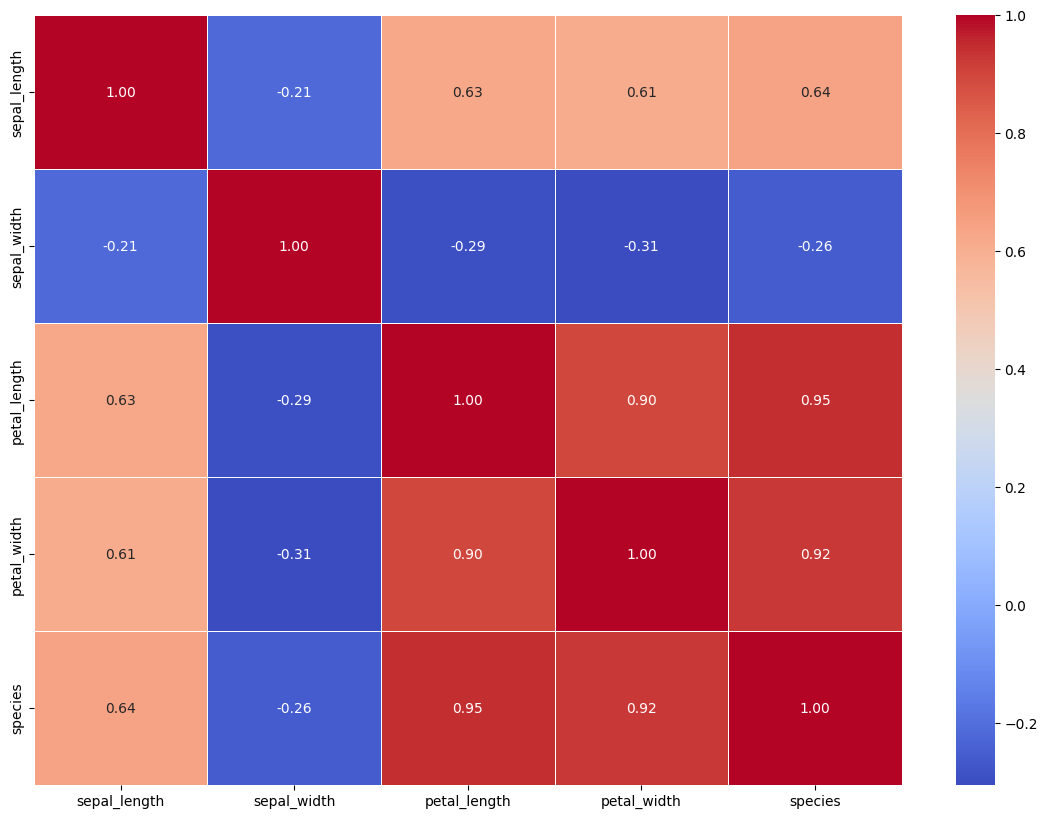

In [17]:
plt.figure(figsize=(14,10))

# Correlation calculation
corr_matrix = df.corr()

# Heatmap with values shown
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,        # 🔥 value দেখাবে
    fmt=".2f",         # 🔢 2 decimal পর্যন্ত
    linewidths=0.5
)

#plt.title("Correlation Matrix Heatmap", fontsize=14)
plt.show()


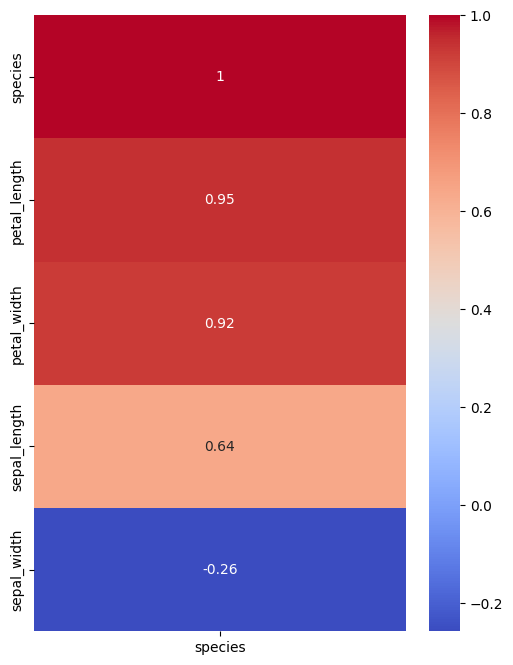

In [18]:

# Correlation with Target


plt.figure(figsize=(6,8))

target_corr = corr_matrix['species'].sort_values(ascending=False)

sns.heatmap(
    target_corr.to_frame(),
    annot=True,
    cmap='coolwarm'
)

#plt.title("Feature Correlation with Typhoid")
plt.show()


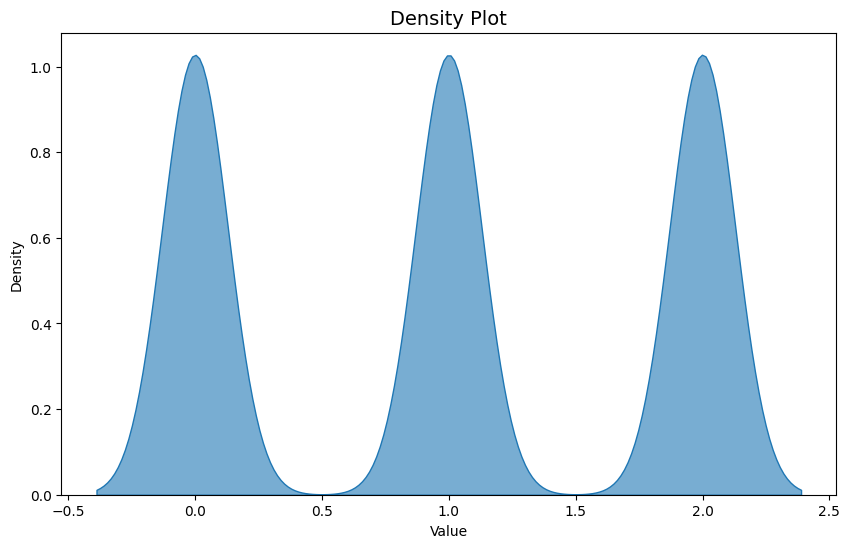

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='species',   # এখানে তোমার column বসাও
    fill=True,
    alpha=0.6
)

plt.title("Density Plot", fontsize=14)
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()


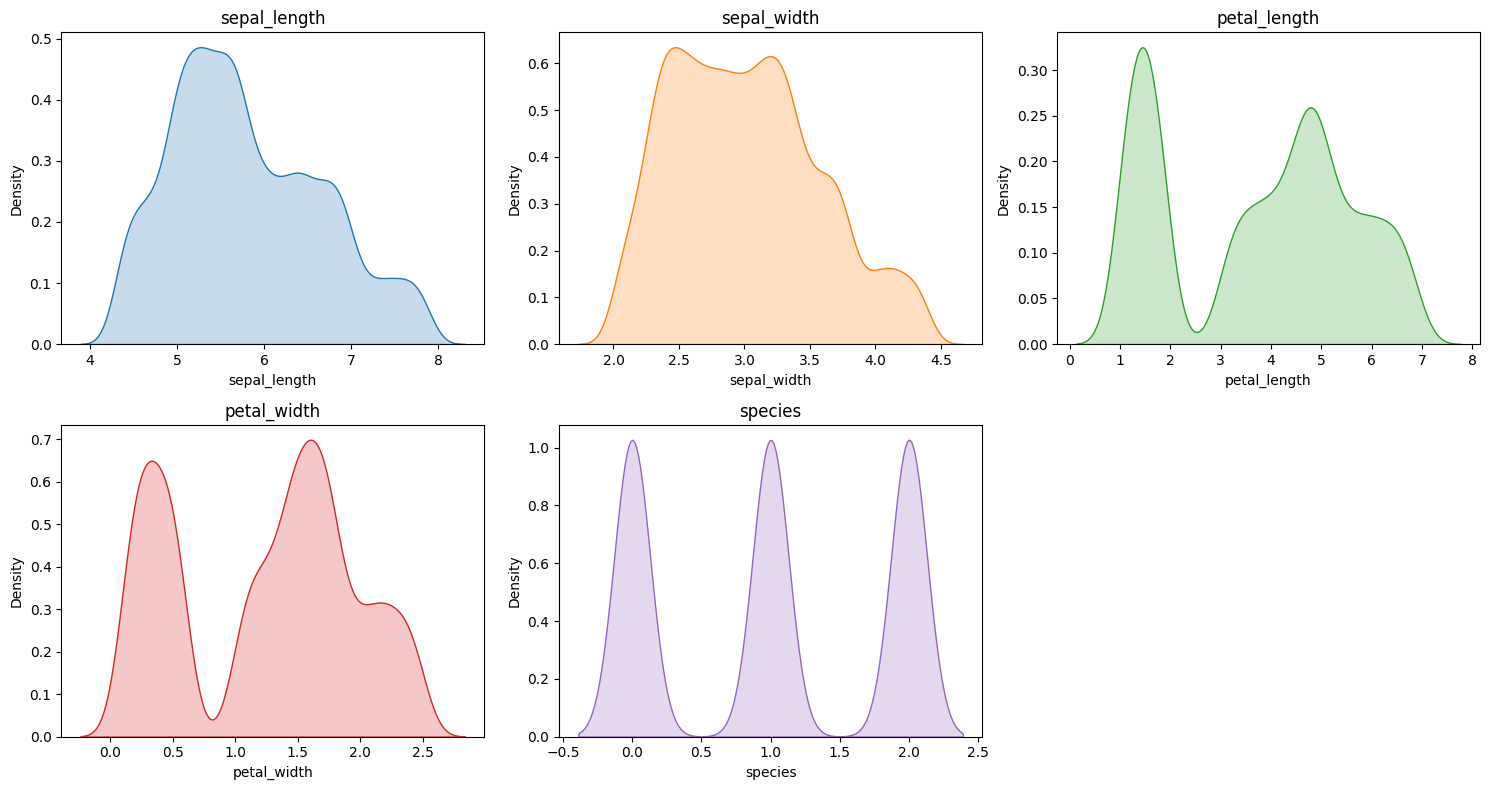

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

colors = sns.color_palette("tab10", len(num_cols))

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    sns.kdeplot(
        df[col].dropna(),   # 🔥 missing value remove
        fill=True,
        color=colors[i]
    )

    plt.title(col)

plt.tight_layout()
plt.show()


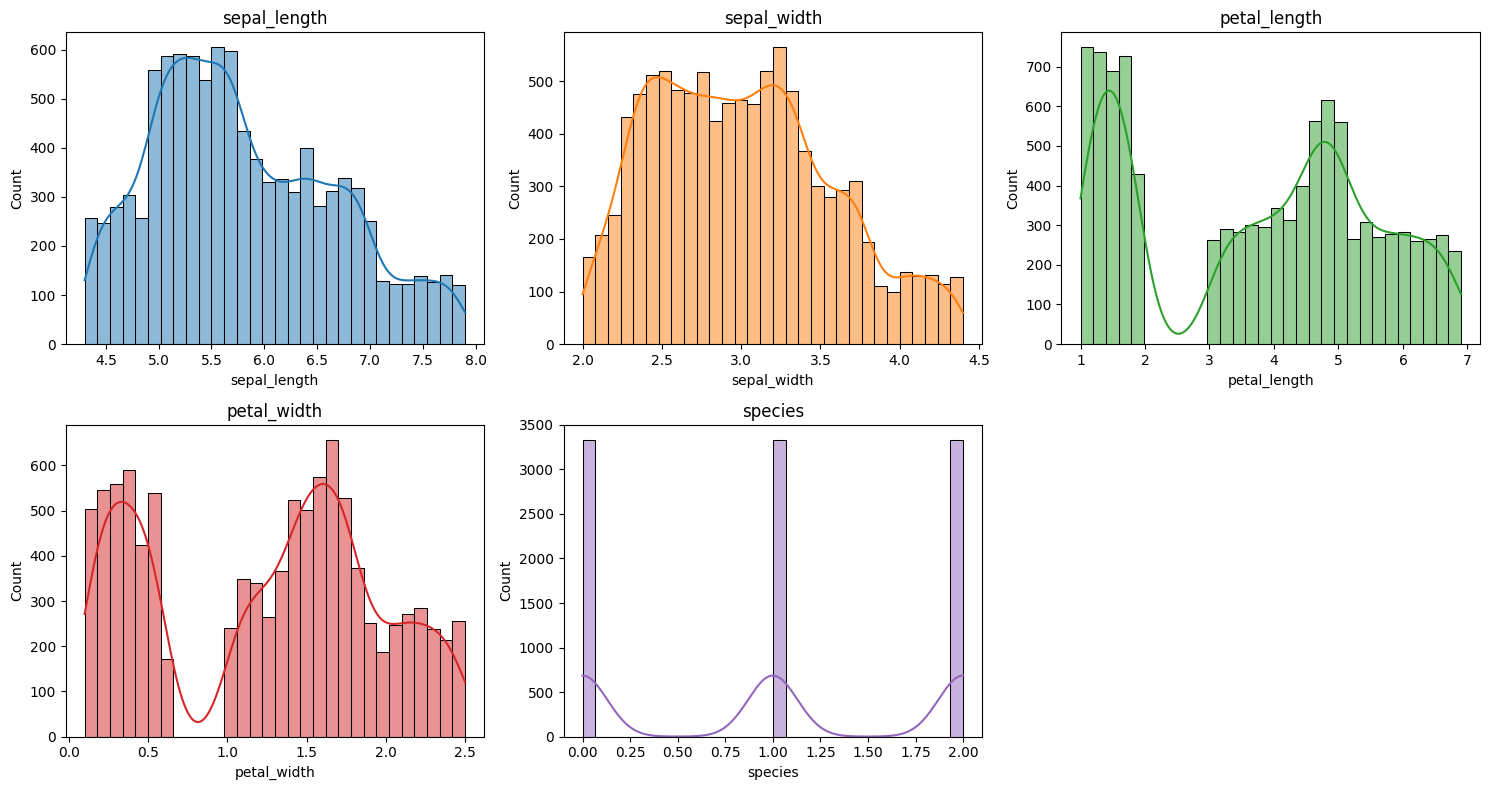

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

colors = sns.color_palette("tab10", len(num_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()   # 🔥 important

for i, col in enumerate(num_cols):
    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        color=colors[i],
        ax=axes[i]
    )
    axes[i].set_title(col)

# 🔥 extra empty plots remove
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


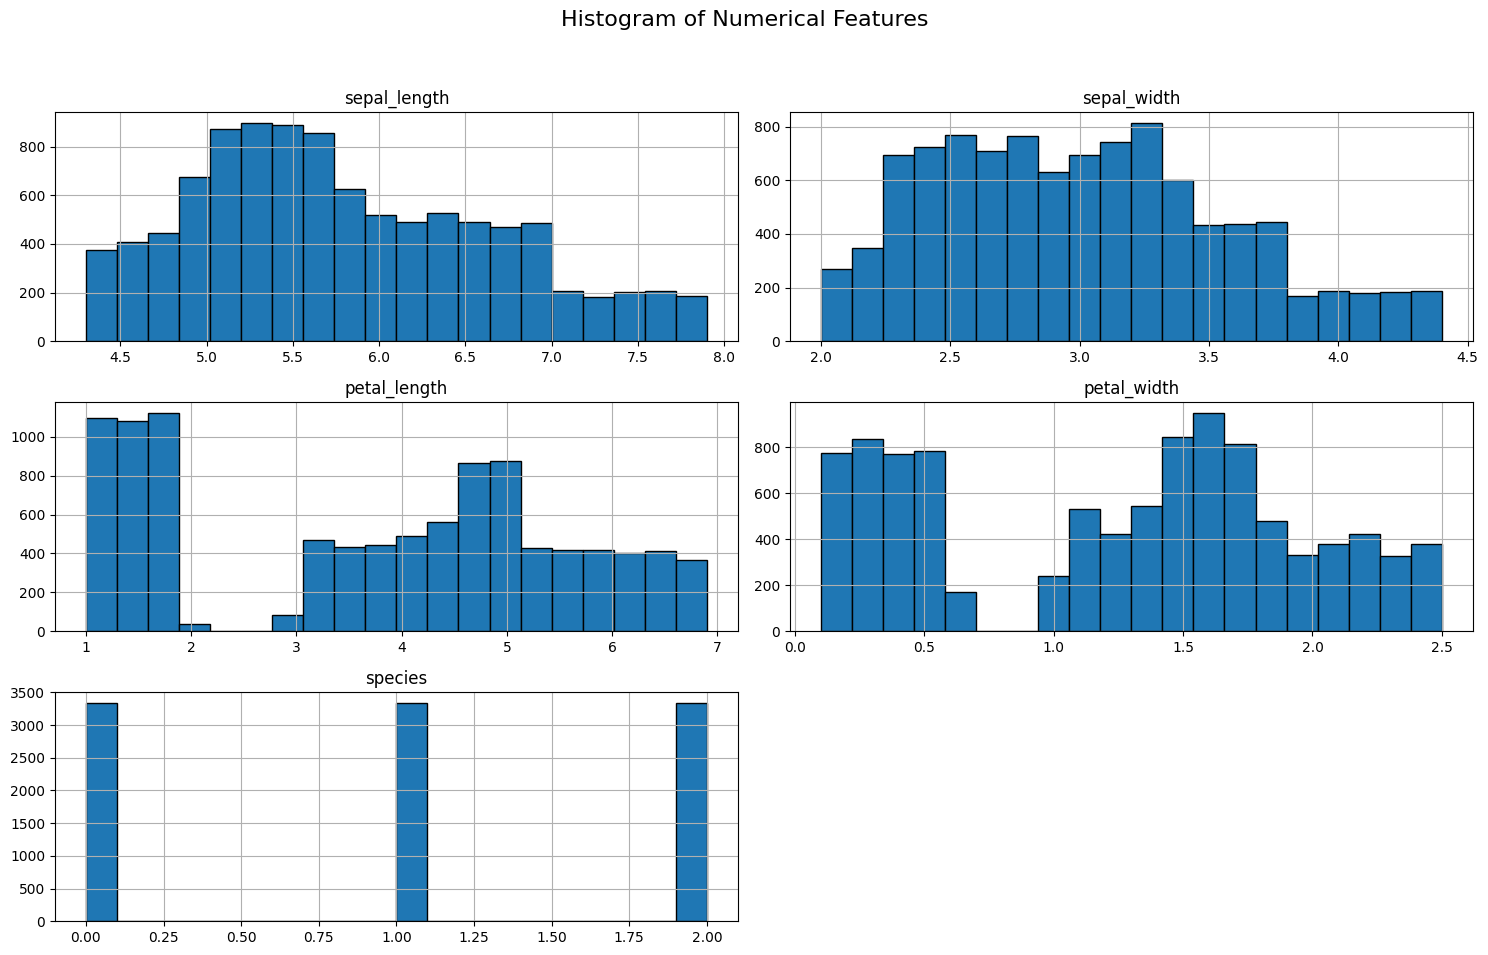

In [22]:
# Histogram for Numerical Features

# Redefine numeric_columns after all transformations
numeric_columns_updated = df.select_dtypes(include=['number']).columns

# Filter out 'Name' as it's an ID and not typically useful for histograms
# Also filter out 'Typhoid' as it's the target variable
columns_to_plot = [col for col in numeric_columns_updated if col not in ['Name', 'Typhoid']]

df[columns_to_plot].hist(
    figsize=(15,10),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Histogram of Numerical Features", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()


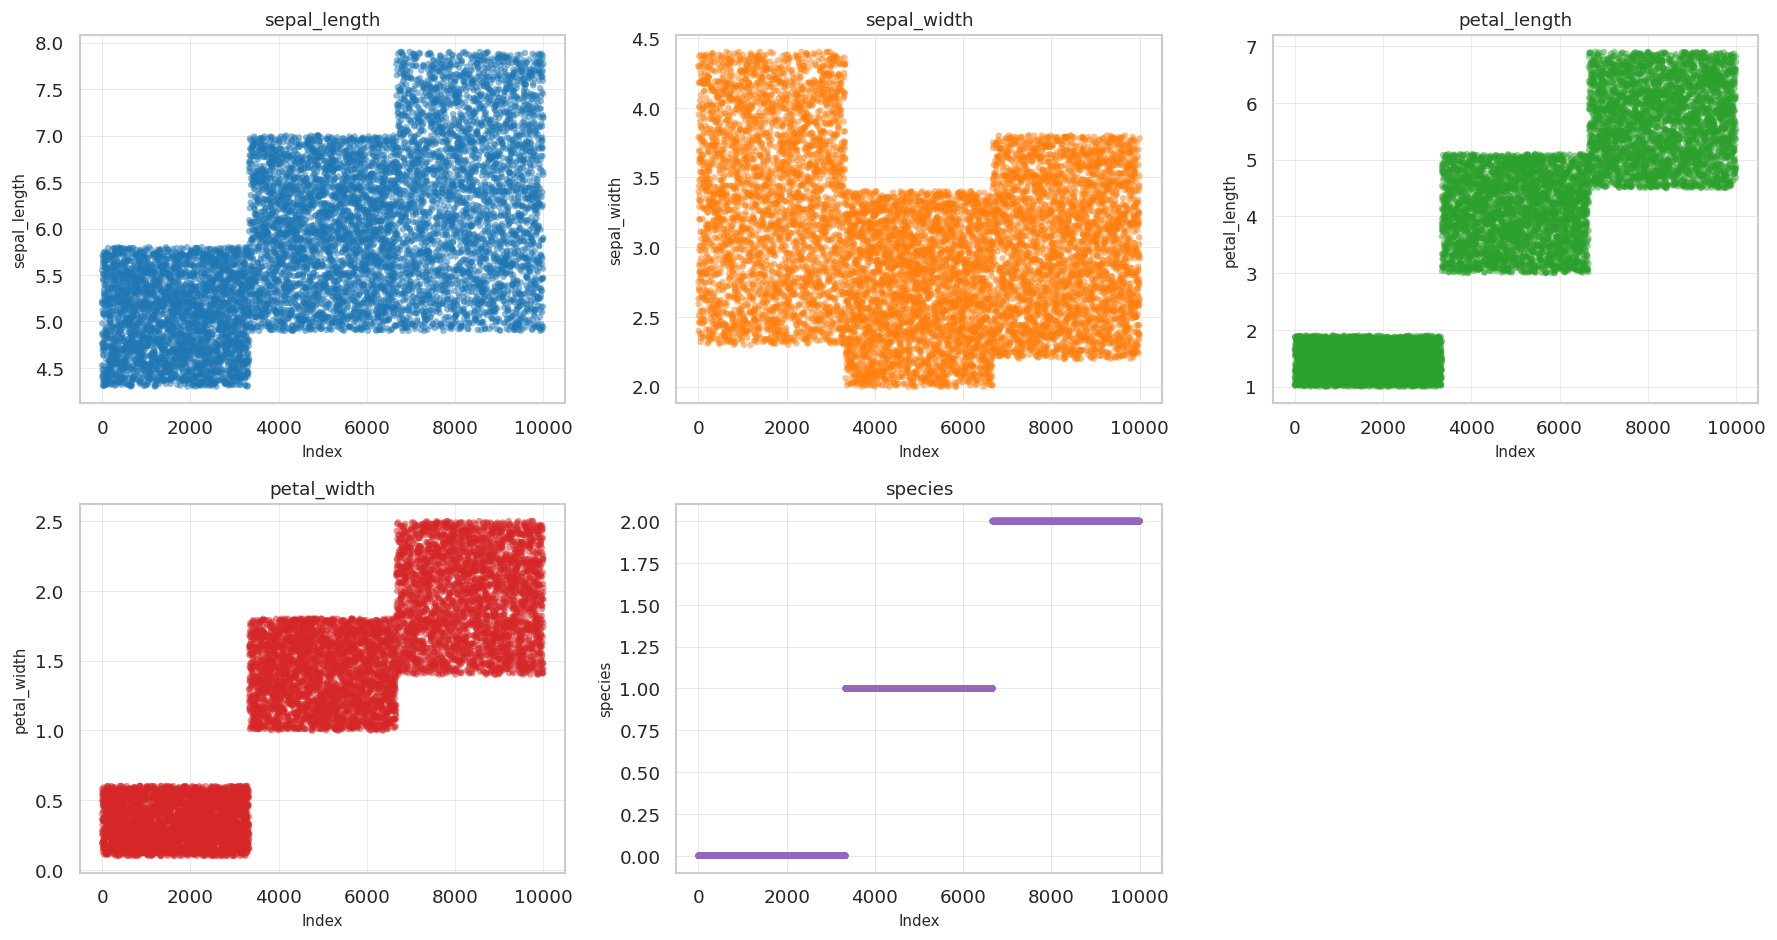

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")  # 🔥 cleaner background

num_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

colors = sns.color_palette("tab10", len(num_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(15, 4 * n_rows),
    dpi=120  # 🔥 sharper figure
)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].scatter(
        df.index,
        df[col],
        s=15,            # 🔥 smaller points
        alpha=0.5,       # 🔥 less overlap
        color=colors[i],
        edgecolors="none"
    )
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("Index", fontsize=9)
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].grid(True, linewidth=0.4, alpha=0.6)

# 🔥 remove extra empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
x = df.drop(columns=['species'])
y = df['species']

In [24]:
print(x)

      sepal_length  sepal_width  petal_length  petal_width
0             4.86         4.30          1.66         0.40
1             4.53         2.63          1.05         0.53
2             5.20         3.79          1.02         0.58
3             5.55         2.75          1.16         0.19
4             4.76         3.40          1.39         0.25
...            ...          ...           ...          ...
9995          6.61         2.37          6.13         1.41
9996          4.94         3.44          4.68         1.74
9997          7.77         3.78          4.89         2.02
9998          6.58         2.92          6.72         2.23
9999          7.19         2.63          5.54         1.94

[10000 rows x 4 columns]


In [25]:
print(x.shape)

(10000, 4)


In [26]:
print(y)

0       0
1       0
2       0
3       0
4       0
       ..
9995    2
9996    2
9997    2
9998    2
9999    2
Name: species, Length: 10000, dtype: int64


In [27]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.25,random_state=2)
model = RandomForestClassifier()
model.fit(xtrain,ytrain)

RandomForestClassifier()

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)


In [29]:
# accuracy on training data
xtrain_prediction = model.predict(xtrain)
training_data_accuracy = accuracy_score(ytrain, xtrain_prediction)

print('Accuracy on training data = ', training_data_accuracy)

Accuracy on training data =  1.0


In [30]:
# accuracy on test data
xtest_prediction = model.predict(xtest)
test_data_accuracy = accuracy_score( xtest_prediction, ytest)

print('Accuracy on test data = ', test_data_accuracy)

Accuracy on test data =  0.9852


In [31]:
# Evaluate the model
conf_matrix = confusion_matrix(ytest, xtest_prediction)
class_report = classification_report(ytest, xtest_prediction)

In [32]:
print("\nClassification Report:\n", class_report)


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       851
           1       0.96      0.99      0.98       791
           2       0.99      0.96      0.98       858

    accuracy                           0.99      2500
   macro avg       0.98      0.99      0.99      2500
weighted avg       0.99      0.99      0.99      2500



In [33]:
print("\nClassification Report:\n", conf_matrix)


Classification Report:
 [[851   0   0]
 [  0 785   6]
 [  0  31 827]]


In [34]:
#random forest+ xg bost hybird model
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

rf = RandomForestClassifier(n_estimators=100, random_state=2)
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=2
)

hybrid_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

hybrid_model.fit(xtrain, ytrain)
y_pred = hybrid_model.predict(xtest)
accuracy = accuracy_score(ytest, y_pred)
print("Hybrid Model Accuracy:", accuracy)

Hybrid Model Accuracy: 0.984


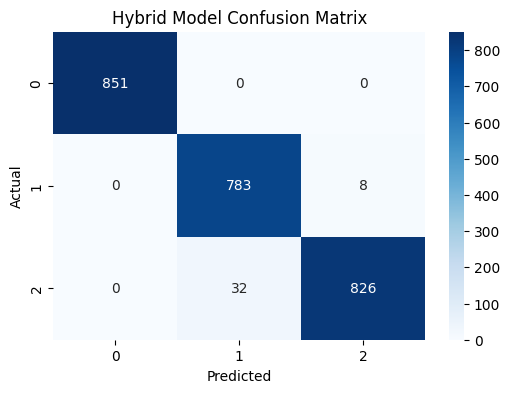

In [35]:
# Generate Confusion Matrix hybrid
cm = confusion_matrix(ytest, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(ytest), yticklabels=np.unique(ytest))
plt.title("Hybrid Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

model = GradientBoostingClassifier(
    n_estimators=60,        # fewer trees
    learning_rate=0.03,     # slower learning
    max_depth=1,            # very shallow trees
    min_samples_split=20,
    min_samples_leaf=10,
    subsample=0.6,
    random_state=42
)

model.fit(xtrain, ytrain)
y_pred = model.predict(xtest)

print("Gradient Boosting Accuracy:", accuracy_score(ytest, y_pred))


Gradient Boosting Accuracy: 0.9688


In [37]:
xtest_prediction = model.predict(xtest)
test_data_accuracy = accuracy_score( xtest_prediction, ytest)

print('Accuracy on test data = ', test_data_accuracy)

Accuracy on test data =  0.9688


In [38]:
input_data = (
    5.1, # sepal_length
    3.5, # sepal_width
    1.4, # petal_length
    0.2  # petal_width
)

# change the input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array as we are predicting for one datapoint
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)

# The original 'species' column has values 0, 1, 2. Let's map these to meaningful labels.
# Assuming 0: Iris-setosa, 1: Iris-versicolor, 2: Iris-virginica

if prediction[0] == 0:
    print('The flower is Iris-setosa')
elif prediction[0] == 1:
    print('The flower is Iris-versicolor')
elif prediction[0] == 2:
    print('The flower is Iris-virginica')

[0]
The flower is Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [39]:
import pickle


filename = 'iris flower classification  prediction.sav'
pickle.dump(model, open(filename, 'wb'))


# loading the saved model
loaded_model = pickle.load(open(filename, 'rb'))

for column in df.columns:
    print(column)

sepal_length
sepal_width
petal_length
petal_width
species


In [40]:
# Import ML Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [41]:
from sklearn import svm

In [42]:
#knn
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(xtrain, ytrain)
knn_pred = knn.predict(xtest)

print("KNN Accuracy:", accuracy_score(ytest, knn_pred))

KNN Accuracy: 0.9792


In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(
    max_depth=2,            # আরও ছোট tree
    min_samples_split=20,   # split কঠিন
    min_samples_leaf=10,    # leaf বড়
    criterion='gini',
    random_state=42
)

dt.fit(xtrain, ytrain)
dt_pred = dt.predict(xtest)

print("Decision Tree Accuracy:", accuracy_score(ytest, dt_pred))


Decision Tree Accuracy: 0.9184


In [44]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=100,          # fewer trees
    max_depth=2,              # very shallow
    learning_rate=0.03,       # slower learning
    subsample=0.6,
    colsample_bytree=0.6,
    reg_alpha=5,              # strong L1
    reg_lambda=5,             # strong L2
    gamma=3,                  # harder splits
    min_child_weight=10,      # restrict leaf growth
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb.fit(xtrain, ytrain)
xgb_pred = xgb.predict(xtest)

print("XGBoost Accuracy:", accuracy_score(ytest, xgb_pred))


XGBoost Accuracy: 0.9788


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [03:24:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [45]:
# Classification Report
print("\nXGBClassifier Classification Report:\n", classification_report(ytest,xgb_pred ))


XGBClassifier Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       851
           1       0.94      1.00      0.97       791
           2       1.00      0.94      0.97       858

    accuracy                           0.98      2500
   macro avg       0.98      0.98      0.98      2500
weighted avg       0.98      0.98      0.98      2500



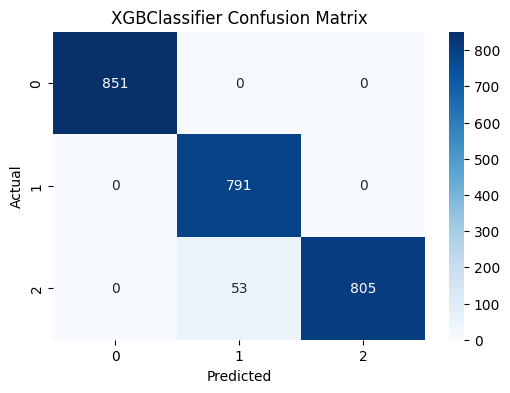

In [46]:
# Generate Confusion Matrix
cm = confusion_matrix(ytest, xgb_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(ytest), yticklabels=np.unique(ytest))
plt.title("XGBClassifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

logs = LogisticRegression(
    C=0.08,
    penalty='l2',
    solver='liblinear',
    max_iter=1000,
    class_weight='balanced'
)

logs.fit(xtrain_scaled, ytrain)
y_pre = logs.predict(xtest_scaled)

print("Accuracy:", accuracy_score(ytest, y_pre))


Accuracy: 0.9436


In [48]:
from sklearn.svm import SVC   # SVM
from sklearn.metrics import accuracy_score

model = SVC(kernel='rbf', random_state=42)
model.fit(xtrain, ytrain)

y_pred = model.predict(xtest)

test_data_accuracy = accuracy_score(ytest, y_pred)
print('Accuracy on test data = ', test_data_accuracy)


Accuracy on test data =  0.9748


In [49]:
from sklearn.naive_bayes import GaussianNB #Naive bayes

model = GaussianNB()
model.fit(xtrain, ytrain)
y_pred = model.predict(xtest)
test_data_accuracy = accuracy_score( y_pred, ytest)
print('Accuracy on test data = ', test_data_accuracy)

Accuracy on test data =  0.9712


In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=30,      # কম tree
    max_depth=4,          # depth কম
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    bootstrap=True,
    random_state=42
)

model.fit(xtrain, ytrain)
y_pred = model.predict(xtest)

print("Random Forest Accuracy:", accuracy_score(ytest, y_pred))


Random Forest Accuracy: 0.9812


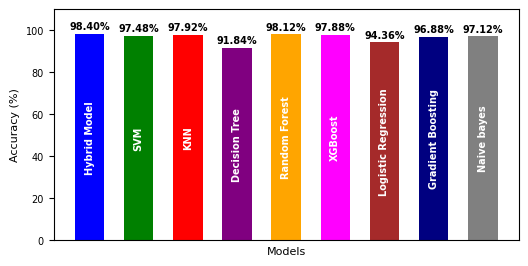

In [51]:
import matplotlib.pyplot as plt

# Data
models = ["Hybrid Model","SVM", "KNN", "Decision Tree", "Random Forest", "XGBoost", "Logistic Regression", "Gradient Boosting","Naive bayes"]
accuracy = [98.4, 97.48, 97.92, 91.84, 98.12, 97.88, 94.36, 96.88, 97.12]

# Plot
plt.figure(figsize=(6, 3))  # Small figure size
bars = plt.bar(models, accuracy, color=['blue', 'green', 'red', 'purple', 'orange', 'magenta', 'brown','navy', 'gray'], width=0.6)

# Add model names inside the bars (centered)
for bar, model in zip(bars, models):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, model, ha='center', va='center',
             fontsize=7, fontweight='bold', color='white', rotation=90)  # Rotated for better fit

# Add accuracy values above the bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{bar.get_height():.2f}%",
             ha='center', fontsize=7, fontweight='bold', color='black')

# Labels and title
plt.xlabel("Models", fontsize=8)
plt.ylabel("Accuracy (%)", fontsize=8)
#plt.title("Model Accuracy on Mental Health Dataset", fontsize=9)
plt.xticks([])  # Remove x-axis labels since names are inside bars
plt.yticks(fontsize=7)
plt.ylim(0, 110)  # Set y-axis limit above 100

# Show plot
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

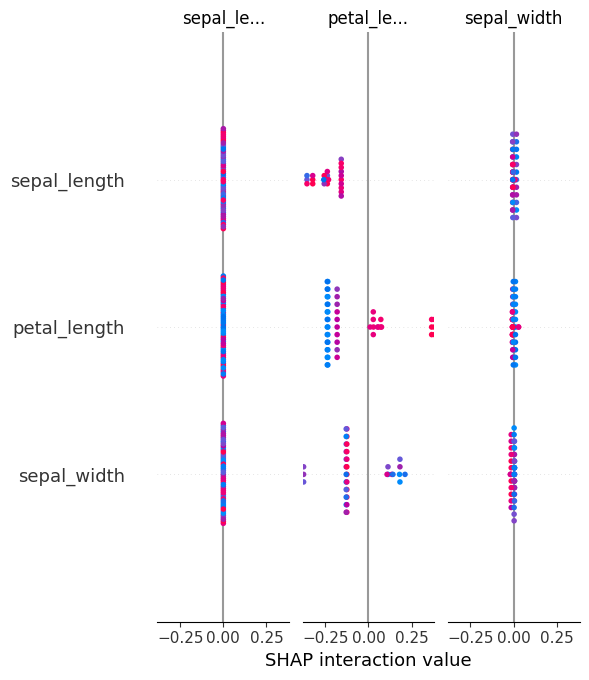

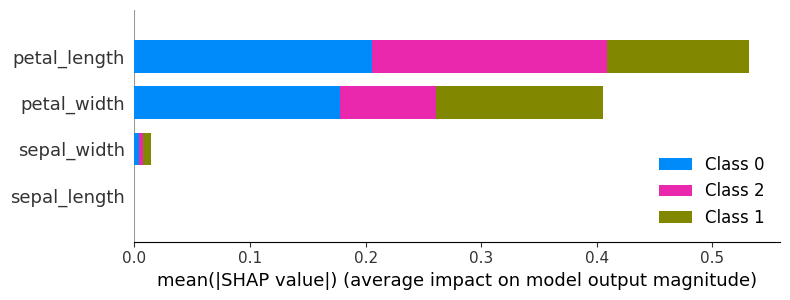

In [52]:
import shap
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier # Import the classifier

# Re-initialize and train the GradientBoostingClassifier
# This is to ensure 'model' is a proper trained object and not a string
model = GradientBoostingClassifier(
    n_estimators=60,        # fewer trees
    learning_rate=0.03,     # slower learning
    max_depth=1,            # very shallow trees
    min_samples_split=20,
    min_samples_leaf=10,
    subsample=0.6,
    random_state=42
)
model.fit(xtrain, ytrain) # Make sure it's trained

# background sample (speed এর জন্য ছোট sample নেওয়া ভালো)
background = shap.sample(xtrain, 100)

explainer = shap.KernelExplainer(model.predict_proba, background)

shap_values = explainer.shap_values(xtest[:50])

shap.summary_plot(shap_values, xtest[:50])
shap.summary_plot(shap_values, xtrain, feature_names=x.columns, plot_type="bar")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [03:24:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


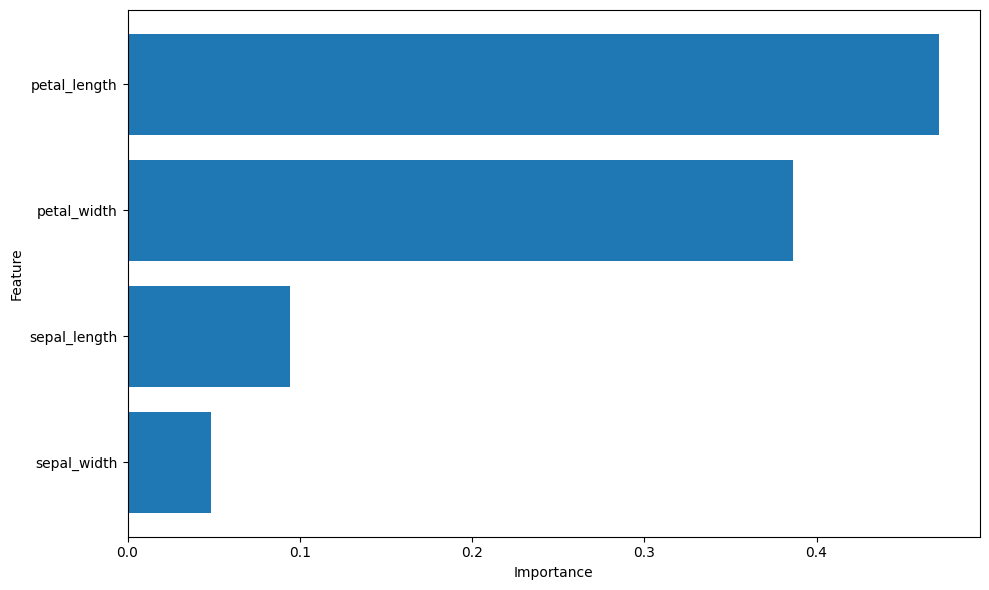

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# =========================
# Train Random Forest
# =========================
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(xtrain, ytrain)

rf_importance = rf.feature_importances_

# =========================
# Train XGBoost
# =========================
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb.fit(xtrain, ytrain)

xgb_importance = xgb.feature_importances_

# =========================
# Ensemble importance (average)
# =========================
ensemble_importance = (rf_importance + xgb_importance) / 2

feature_names = xtrain.columns

fi_df = pd.DataFrame({
    "Feature": feature_names,
    "RF Importance": rf_importance,
    "XGB Importance": xgb_importance,
    "Ensemble Importance": ensemble_importance
})

# Sort by ensemble importance
fi_df = fi_df.sort_values(by="Ensemble Importance", ascending=True)

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.barh(
    fi_df["Feature"],
    fi_df["Ensemble Importance"]
)

#plt.title("Ensemble Feature Importance (Random Forest + XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [03:24:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


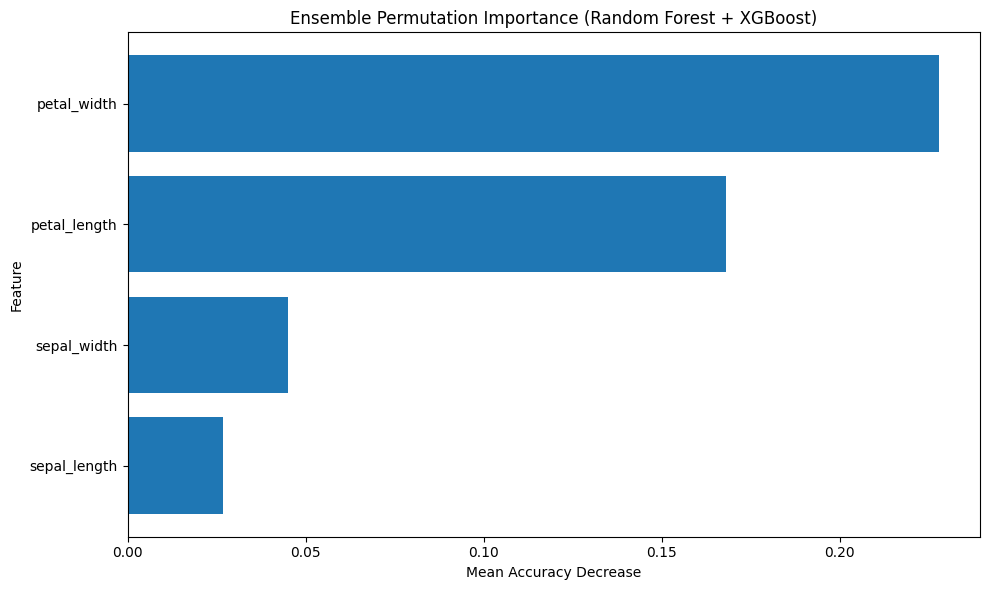

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

# =========================
# Train Random Forest
# =========================
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(xtrain, ytrain)

rf_perm = permutation_importance(
    rf,
    xtest,
    ytest,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

rf_importance = rf_perm.importances_mean

# =========================
# Train XGBoost
# =========================
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42
)
xgb.fit(xtrain, ytrain)

xgb_perm = permutation_importance(
    xgb,
    xtest,
    ytest,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

xgb_importance = xgb_perm.importances_mean

# =========================
# Ensemble permutation importance (average)
# =========================
ensemble_importance = (rf_importance + xgb_importance) / 2

feature_names = xtest.columns

fi_df = pd.DataFrame({
    "Feature": feature_names,
    "RF Permutation": rf_importance,
    "XGB Permutation": xgb_importance,
    "Ensemble Permutation": ensemble_importance
})

# Sort by ensemble importance
fi_df = fi_df.sort_values(by="Ensemble Permutation", ascending=True)

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.barh(
    fi_df["Feature"],
    fi_df["Ensemble Permutation"]
)

plt.title("Ensemble Permutation Importance (Random Forest + XGBoost)")
plt.xlabel("Mean Accuracy Decrease")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


In [55]:
pip install shap


In [56]:
print(model)
print(type(model))


GradientBoostingClassifier(learning_rate=0.03, max_depth=1, min_samples_leaf=10,
                           min_samples_split=20, n_estimators=60,
                           random_state=42, subsample=0.6)
<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>


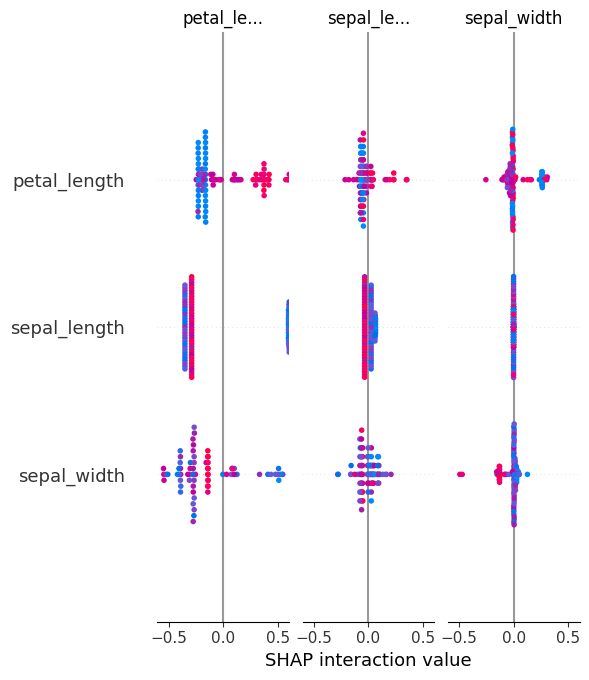

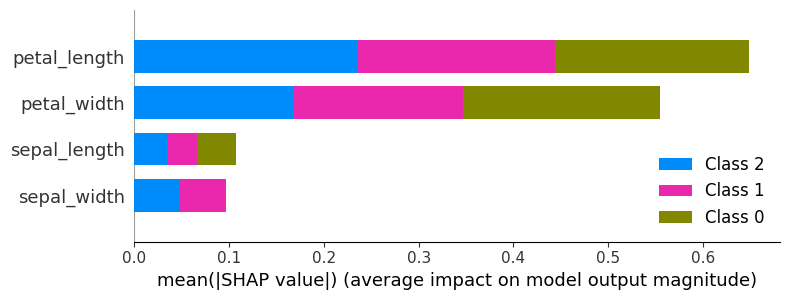

In [58]:
# =======================
# XAI 4: SHAP (Tree-based Models)
# =======================

import shap
from sklearn.ensemble import RandomForestClassifier

# Re-initialize and fit RandomForestClassifier to ensure 'model' is a tree-based model
# TreeExplainer works best for tree models and supports multi-class for RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(xtrain, ytrain)

explainer = shap.TreeExplainer(model)

# Use a small sample for speed and to avoid potential memory issues with large datasets
X_sample = xtrain.sample(100, random_state=42)

shap_values = explainer.shap_values(X_sample)

# Summary Plot (Global Explanation)
shap.summary_plot(shap_values, X_sample, feature_names=x.columns)
shap.summary_plot(shap_values, X_sample, feature_names=x.columns, plot_type="bar")

Shape of shap_values (single array): (2500, 4, 3)
Shape of xtest.values: (2500, 4)


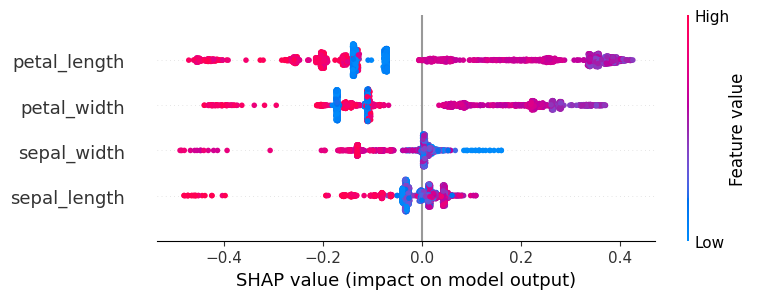

In [59]:
import shap
import numpy as np # Ensure numpy is imported for shape checks

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(xtest)

# Debugging: Print shapes just before the summary_plot call
if isinstance(shap_values, list):
    print(f"Shape of shap_values (list of arrays): {[s.shape for s in shap_values]}")
    print(f"Shape of shap_values[1]: {shap_values[1].shape}")
else:
    # This case is unlikely for a multi-class TreeExplainer, but included for robustness
    print(f"Shape of shap_values (single array): {shap_values.shape}")
print(f"Shape of xtest.values: {xtest.values.shape}")


# SHAP summary (beeswarm) plot
shap.summary_plot(
    shap_values[:, :, 1],   # Correctly select SHAP values for class 1
    xtest.values,     # Convert DataFrame to numpy array
    feature_names=xtest.columns.tolist(), # Explicitly provide feature names
    plot_type="dot"
)

In [61]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=646f82c2156486146429685970525fb92f4bf6967bf5eb9ed4b9f4aae6dbf71f
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


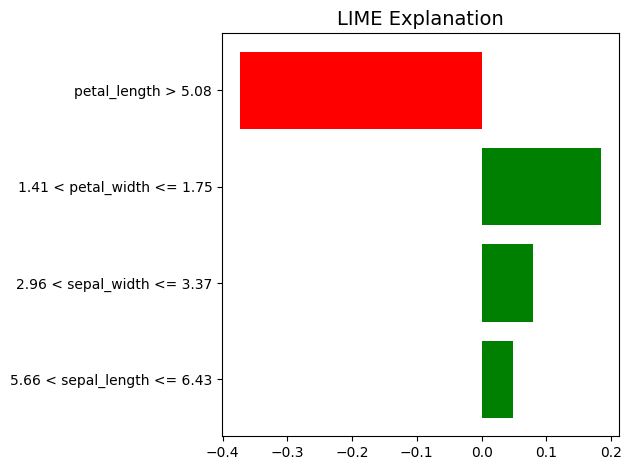

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

# Feature & class names
feature_names = x.columns.tolist()
#class_names = ["Minimal", "Negative", "Positive"]

# Create explainer
explainer = LimeTabularExplainer(
    training_data=np.array(xtrain),
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True
)

# Explain one instance
i = 0
exp = explainer.explain_instance(
    data_row=xtest.iloc[i].values,
    predict_fn=model.predict_proba,
    num_features=10
)

# Convert to matplotlib figure
fig = exp.as_pyplot_figure()

# Improve colors & style
plt.title("LIME Explanation", fontsize=14)
plt.tight_layout()

# Save as JPEG
plt.savefig("lime_explanation.jpeg", dpi=300, bbox_inches="tight")
plt.show()


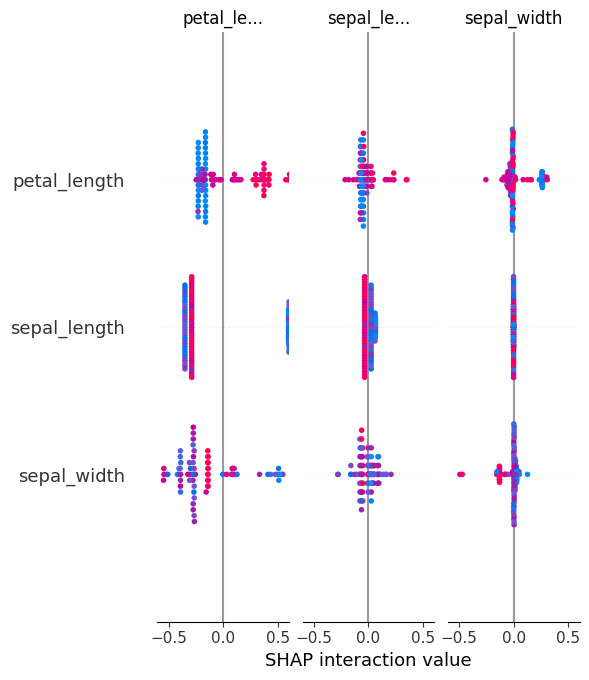

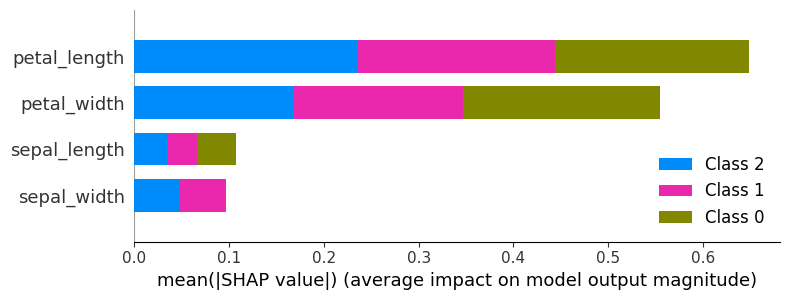

In [63]:
# =======================
# XAI 4: SHAP (Tree-based Models)
# =======================

import shap
from sklearn.ensemble import RandomForestClassifier

# Re-initialize and fit RandomForestClassifier to ensure 'model' is a tree-based model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(xtrain, ytrain)

# TreeExplainer works best for tree models
explainer = shap.TreeExplainer(model)

# Use a small sample for speed
X_sample = xtrain.sample(100, random_state=42)

shap_values = explainer.shap_values(X_sample)

# Summary Plot (Global Explanation)
shap.summary_plot(shap_values, X_sample, feature_names=x.columns)
shap.summary_plot(shap_values, xtest, plot_type="bar")

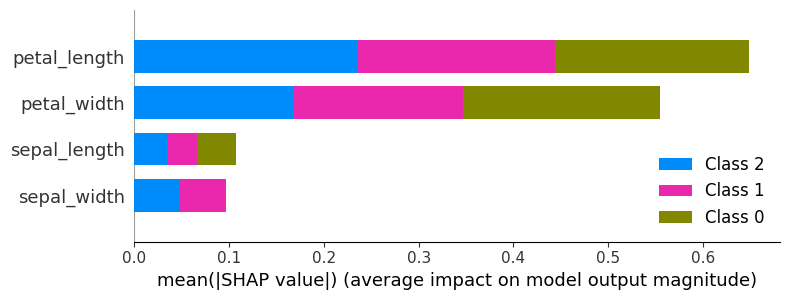

In [64]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=x.columns,
    plot_type="bar"
)

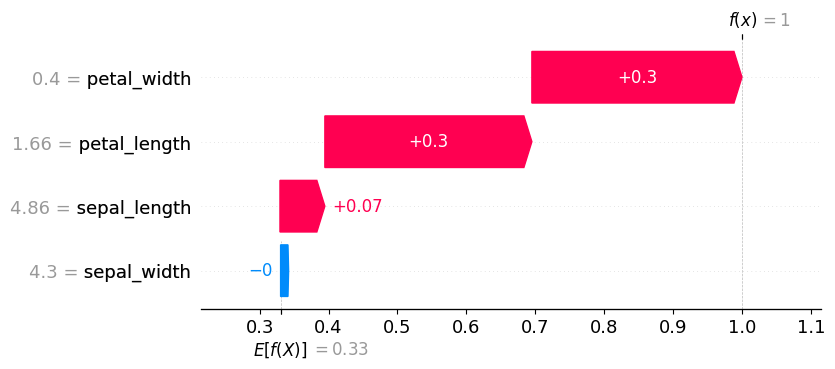

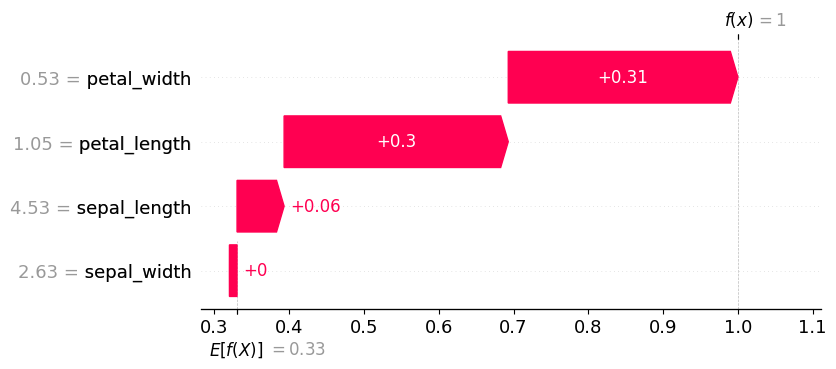

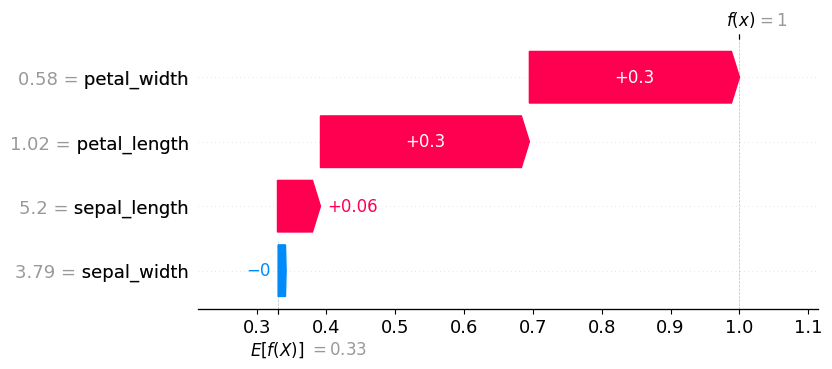

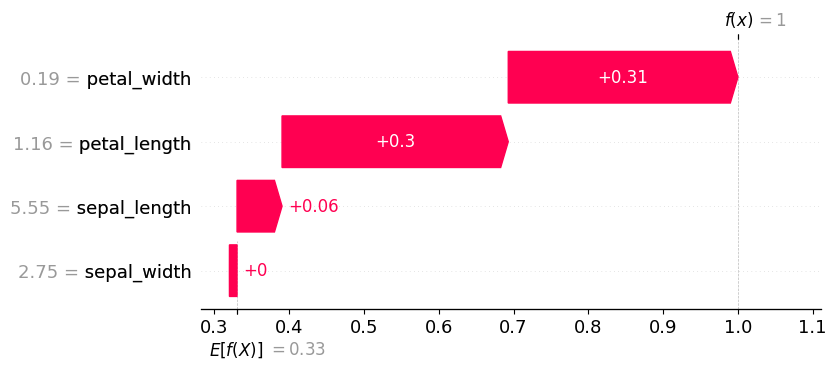

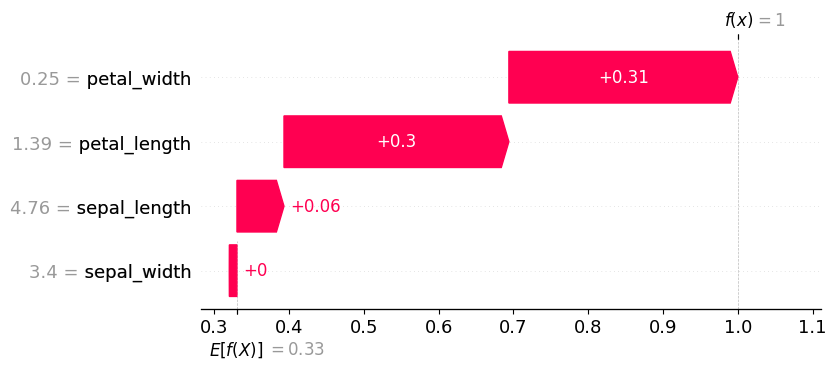

In [68]:
import shap

explainer = shap.TreeExplainer(model)

# SHAP values for all samples in x
# For multi-class models, shap_values is typically a list of arrays, one for each class.
# Each array shap_values[k] will have shape (num_samples, num_features).
multi_class_shap_values = explainer.shap_values(x)

# Choose a subset of samples to plot waterfall for, e.g., the first 5 or 10.
# Plotting for all 655 samples is generally not practical and can freeze your notebook.
num_samples_to_plot = min(len(x), 5) # Plotting for a maximum of 5 samples

for i in range(num_samples_to_plot):
    # Select the target class to explain. For example, class 0 (Minimal Typhoid).
    # You can change this to 1 for Negative or 2 for Positive, or loop through classes.
    target_class_idx = 0

    # Get the SHAP values for the current sample (i) and the chosen target class
    # This will be a 1D array of shape (num_features,)
    sample_shap_values = multi_class_shap_values[i, :, target_class_idx]

    # Get the base value (expected value) for the chosen target class
    base_value = explainer.expected_value[target_class_idx]

    # Get the feature values for the current sample
    sample_feature_values = x.iloc[i]

    # Create an Explanation object for the waterfall plot
    explanation = shap.Explanation(
        values=sample_shap_values,
        base_values=base_value,
        data=sample_feature_values,
        feature_names=x.columns.tolist()
    )

    # Generate the waterfall plot
    shap.waterfall_plot(explanation)



Top Important Features:

        Feature  Importance
2  petal_length    0.490039
3   petal_width    0.393164
0  sepal_length    0.082846
1   sepal_width    0.033951


/tmp/ipython-input-1046369806.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


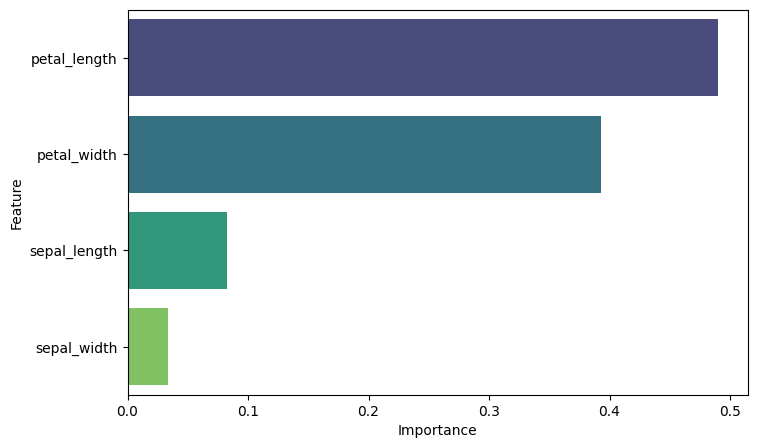

In [67]:

# XAI 1: Feature Importance (Tree-based Models)


# Re-initialize and fit RandomForestClassifier to ensure 'model' is a tree-based model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(xtrain, ytrain)

feature_importance = model.feature_importances_
feature_names = x.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

print("\nTop Important Features:\n")
print(importance_df.head(10))

# Plot
plt.figure(figsize=(8,5))
sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature',
    palette='viridis'
)
#plt.title("Top 10 Important Features (Random Forest Model)")
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [03:29:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/tmp/ipython-input-2730789974.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



Top Important Features (Ensemble Model):

        Feature  Ensemble Importance
2  petal_length             0.471348
3   petal_width             0.386280
0  sepal_length             0.094150
1   sepal_width             0.048223


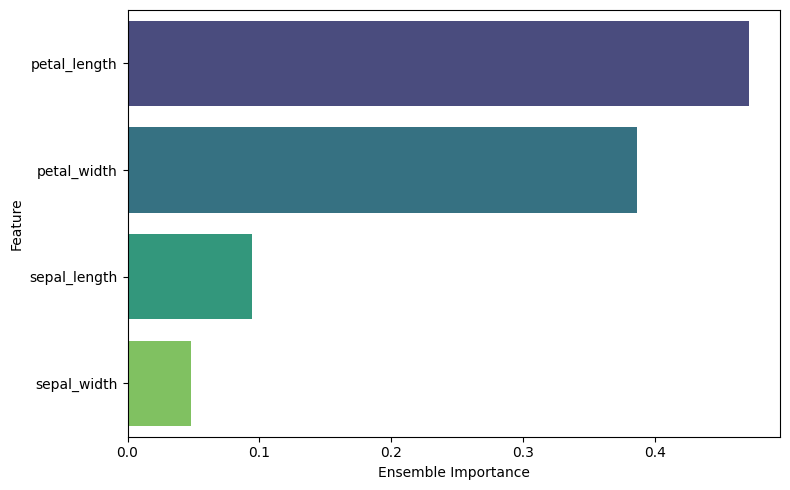

In [69]:
# XAI 1: Feature Importance (Ensemble: Random Forest + XGBoost)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# =========================
# Train Random Forest
# =========================
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(xtrain, ytrain)
rf_importance = rf.feature_importances_

# =========================
# Train XGBoost
# =========================
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42
)
xgb.fit(xtrain, ytrain)
xgb_importance = xgb.feature_importances_

# =========================
# Ensemble Importance (Average)
# =========================
ensemble_importance = (rf_importance + xgb_importance) / 2
feature_names = x.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "RF Importance": rf_importance,
    "XGB Importance": xgb_importance,
    "Ensemble Importance": ensemble_importance
}).sort_values(by="Ensemble Importance", ascending=False)

print("\nTop Important Features (Ensemble Model):\n")
print(importance_df[["Feature", "Ensemble Importance"]].head(10))

# =========================
# Plot
# =========================
plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance_df.head(10),
    x="Ensemble Importance",
    y="Feature",
    palette="viridis"
)

#plt.title("Top 10 Important Features (Ensemble: RF + XGBoost)")
plt.xlabel("Ensemble Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



Logistic Regression Feature Effects:

        Feature  Coefficient
1   sepal_width     0.734528
0  sepal_length    -0.812347
2  petal_length    -2.632965
3   petal_width    -2.739209


/tmp/ipython-input-1787090992.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


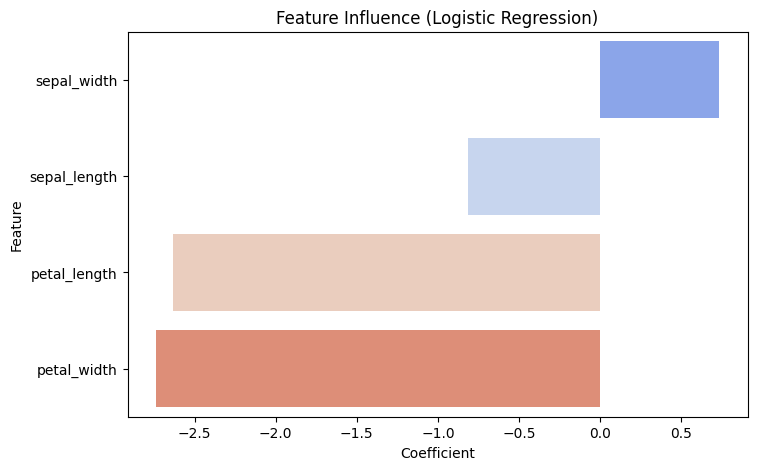

In [70]:

# XAI 2: Logistic Regression Coefficients


coef_df = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': logs.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nLogistic Regression Feature Effects:\n")
print(coef_df)

plt.figure(figsize=(8,5))
sns.barplot(
    data=coef_df,
    x='Coefficient',
    y='Feature',
    palette='coolwarm'
)
plt.title("Feature Influence (Logistic Regression)")
plt.show()



Permutation Importance:

        Feature  Importance
2  petal_length     0.20140
3   petal_width     0.15652
1   sepal_width     0.07652
0  sepal_length     0.04108


/tmp/ipython-input-1833077469.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


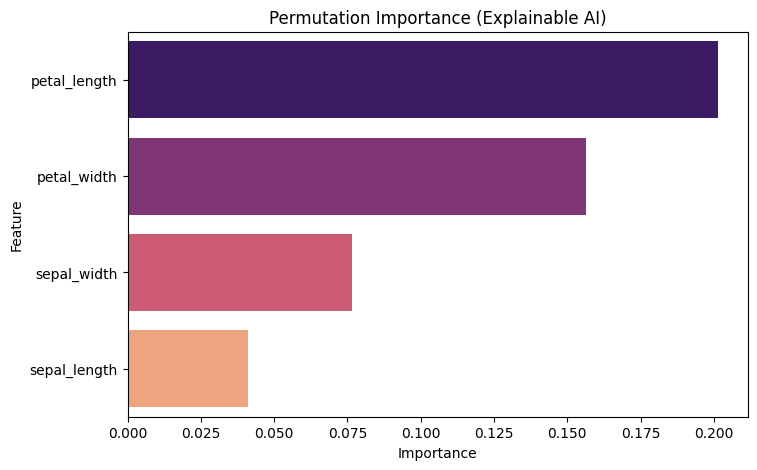

In [71]:

# XAI 3: Permutation Importance (Model-Agnostic)


from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    model,
    xtest,
    ytest,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

perm_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

print("\nPermutation Importance:\n")
print(perm_df.head(10))

plt.figure(figsize=(8,5))
sns.barplot(
    data=perm_df.head(10),
    x='Importance',
    y='Feature',
    palette='magma'
)
plt.title("Permutation Importance (Explainable AI)")
plt.show()


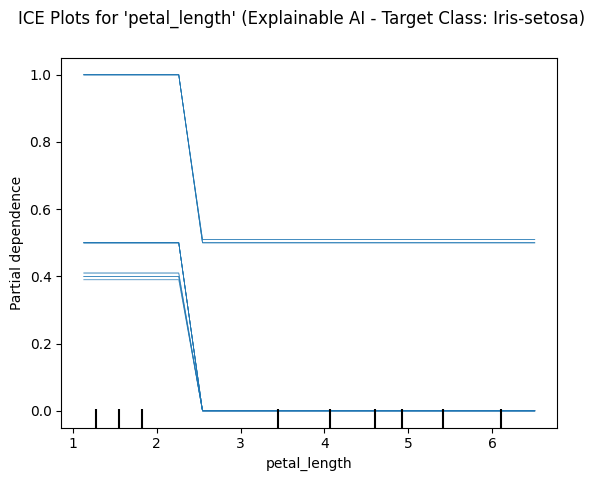

In [73]:

# XAI 5: ICE (Individual Conditional Expectation)


from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Select an actual input feature to plot (e.g., 'TH' or 'TO' from previous analysis)
# The target variable 'Typhoid' is not a valid feature for PDP/ICE plots.
features_for_ice = [ 'petal_length'] # Example: using 'petal_length' as an important feature

# For multi-class classification, the 'target' parameter must be specified
# to indicate which class's partial dependence to plot.
# Assuming 0: Iris-setosa, 1: Iris-versicolor, 2: Iris-virginica
PartialDependenceDisplay.from_estimator(
    model,
    xtrain,
    features_for_ice,
    kind='individual',   # ICE
    subsample=50,
    grid_resolution=20,
    target=0 # Specify the target class (e.g., 0 for 'Iris-setosa')
)

plt.suptitle("ICE Plots for 'petal_length' (Explainable AI - Target Class: Iris-setosa)")
plt.show()

 98%|===================| 7331/7500 [00:50<00:01]       

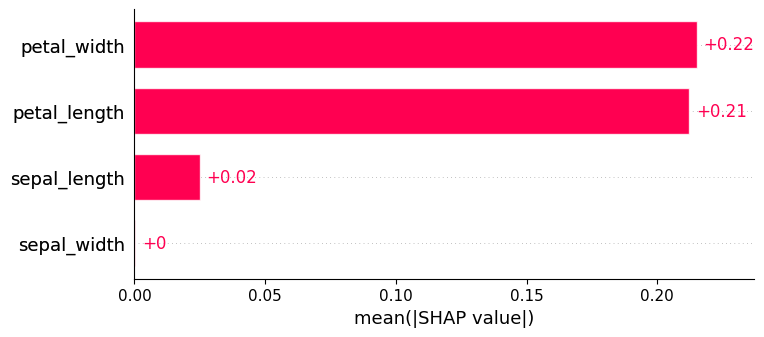

In [82]:
import shap
import matplotlib.pyplot as plt

# Explainer
explainer = shap.Explainer(model, xtest)

# Pass check_additivity=False to the call method to disable the additivity check
shap_values = explainer(xtest, check_additivity=False)

# Select mean absolute SHAP values for a specific class (e.g., class 0)
# shap_values.values is (num_samples, num_features, num_classes)
# shap_values[:, :, 0] selects Explanation object for class 0, values will be (num_samples, num_features)
# .abs.mean(0) then averages absolute SHAP values across samples, resulting in 1D Explanation object
shap_values_class1 = shap_values[:, :, 0].abs.mean(0)

# Feature Importance Bar Plot
shap.plots.bar(
    shap_values_class1,
    max_display=15
)

plt.show()

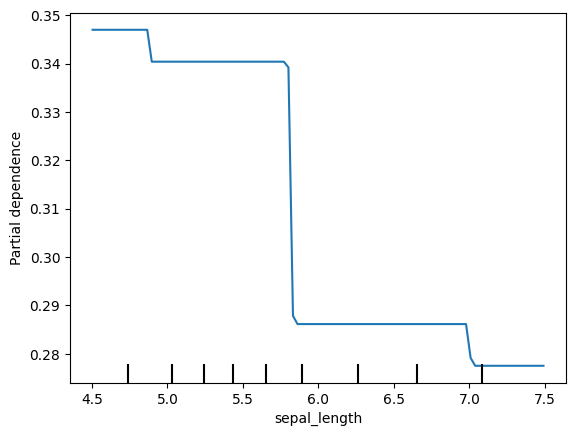

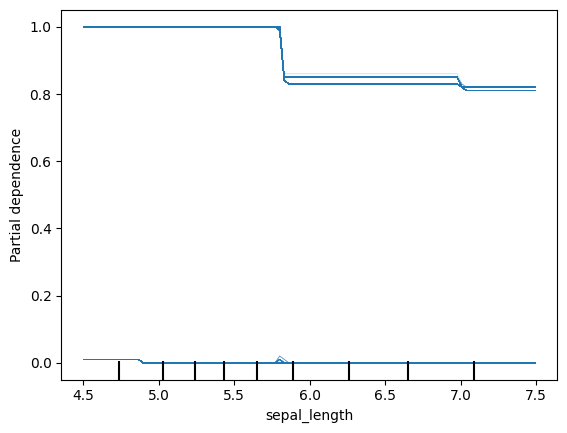

In [78]:

# PDP & ICE
PartialDependenceDisplay.from_estimator(
    model, xtest, features=[0], feature_names=x.columns, target=0
)
plt.show()

PartialDependenceDisplay.from_estimator(
    model, xtest, features=[0], kind="individual", feature_names=x.columns, target=0
)
plt.show()


In [81]:
!pip install lime
